<a href="https://colab.research.google.com/github/rupam0708/Climate-Adaptive_Dynamic_Motor_Risk_Engine/blob/main/Climate_Adaptive_Dynamic_Motor_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install pandas requests geopy

**Data Enrichment**

The goal is to transform the static CSV into a "Dynamic Dataset" by merging it with real-time environmental signals. In the insurance industry, this is the first step toward Contextual Underwriting. An insurer needs to "see" the rain coming to manage the risk of the vehicles they cover.

Task Breakdown


1.   Coordinate Mapping: Since the data uses region_code (e.g., C1, C2), we map these to Latitude and Longitude.
2.   Weather API Integration: We use the Open-Meteo API (Free/No Key required) to fetch current precipitation and wind speed.
3.   Data Merging: Combining the weather features with the existing 41 columns.

In [12]:
import pandas as pd
import requests
import time

# 1. Load your original dataset
df = pd.read_csv('Insurance_claims_data.csv')

# 2. Define Region Mapping (GPS Coordinates for Indian Cities)
# These represent the 'C' codes in your dataset mapped to approximate major hubs
region_coords = {
    'C1': [22.57, 88.36], 'C2': [19.07, 72.87], 'C3': [28.61, 77.20],
    'C4': [13.08, 80.27], 'C5': [12.97, 77.59], 'C6': [17.38, 78.48],
    'C7': [23.02, 72.57], 'C8': [26.84, 80.94], 'C9': [18.52, 73.85],
    'C10': [22.71, 75.85], 'C11': [21.14, 79.08], 'C12': [26.21, 78.17],
    'C13': [21.17, 72.83], 'C14': [26.91, 75.78], 'C15': [25.59, 85.13],
    'C16': [23.25, 77.41], 'C17': [30.73, 76.77], 'C18': [15.29, 73.98],
    'C19': [20.29, 85.82], 'C20': [23.34, 85.30], 'C21': [24.58, 73.71],
    'C22': [10.85, 76.27]
}

# Apply Latitude and Longitude based on region_code
df['lat'] = df['region_code'].apply(lambda x: region_coords.get(x, [0, 0])[0])
df['lon'] = df['region_code'].apply(lambda x: region_coords.get(x, [0, 0])[1])

# 3. Function to fetch weather from Open-Meteo API
def fetch_weather(lat, lon):
    if lat == 0: return 0.0, 0.0

    # We fetch precipitation (rain) and max wind speed
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum,wind_speed_10m_max&timezone=auto"

    try:
        response = requests.get(url)
        data = response.json()
        rain = data['daily']['precipitation_sum'][0] # Today's rain in mm
        wind = data['daily']['wind_speed_10m_max'][0] # Max wind speed in km/h
        return rain, wind
    except Exception as e:
        return 0.0, 0.0

# 4. Augment the Dataset
print("Fetching real-time weather data for regions...")
# We unique the regions first to avoid redundant API calls (Efficiency)
unique_regions = df[['region_code', 'lat', 'lon']].drop_duplicates()
unique_regions[['current_rain', 'max_wind']] = unique_regions.apply(
    lambda r: pd.Series(fetch_weather(r['lat'], r['lon'])), axis=1
)

# Merge back to the main dataframe
df = df.merge(unique_regions[['region_code', 'current_rain', 'max_wind']], on='region_code', how='left')

# 5. Save the augmented data for the next step (EDA)
df.to_csv('Step_1_Augmented_Data.csv', index=False)
print("Step 1 Successful: 'Step_1_Augmented_Data.csv' created.")
print(df[['policy_id', 'region_code', 'current_rain', 'max_wind']].head())

Fetching real-time weather data for regions...
Step 1 Successful: 'Step_1_Augmented_Data.csv' created.
   policy_id region_code  current_rain  max_wind
0  POL045360          C8           0.0      11.4
1  POL016745          C2           0.0      17.4
2  POL007194          C8           0.0      11.4
3  POL018146         C10           0.0      14.5
4  POL049011         C13           0.0      12.7


In [13]:
df.head(10)

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status,lat,lon,current_rain,max_wind
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,No,Yes,Yes,3,0,26.84,80.94,0.0,11.4
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,Yes,Yes,Yes,Yes,4,0,19.07,72.87,0.0,17.4
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,No,Yes,Yes,3,0,26.84,80.94,0.0,11.4
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,0,0,22.71,75.85,0.0,14.5
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,No,Yes,Yes,5,0,21.17,72.83,0.0,12.7
5,POL053680,3.1,2.0,36,C7,6112,B2,M7,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,0,0,23.02,72.57,0.0,13.1
6,POL053943,4.5,2.4,38,C2,27003,C2,M4,Diesel,250Nm@2750rpm,...,Yes,No,Yes,Yes,3,0,19.07,72.87,0.0,17.4
7,POL002857,10.7,2.0,56,C2,27003,B2,M6,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,2,0,19.07,72.87,0.0,17.4
8,POL028225,10.7,0.6,55,C5,34738,B1,M8,CNG,82.1Nm@3400rpm,...,No,No,Yes,Yes,2,0,12.97,77.59,5.8,14.3
9,POL047631,0.3,2.4,45,C3,4076,B2,M6,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,2,0,28.61,77.20,0.0,6.4


Why are we doing this?

In a standard insurance company, the Underwriting Department uses historical tables. By writing this code, we are showcasing:



*   External Data Ingestion: The ability to bring in 3rd party API data.
*   Operational Efficiency: Instead of calling the API 58,000 times (once for each policy), the code only calls it for unique regions, saving time and resources.
*   Foundation for Dynamic Pricing: We now have the variables needed to calculate a "Risk Surge" premium during monsoon seasons.

**Analysis & Feature Engineering**

In this step, we transform the raw, messy data into clean, mathematical features that a Machine Learning model can understand. We also start looking for the "Signal" in the "Noise"—identifying which factors actually correlate with a claim_status.

Task Breakdown



*   Technical Parsing: The max_torque and max_power columns are currently strings (e.g., "250Nm@2750rpm"). We need to extract the numbers to calculate "Engine Stress."
*   Safety Score Synthesis: We will combine multiple binary safety features into a single numerical index.
* Encoding: Machine Learning models can't read "Petrol" or "Manual"; we must convert these categorical strings into numbers.
* Exploratory Data Analysis (EDA): Visualizing the relationship between your new environmental data and the risk of a claim.

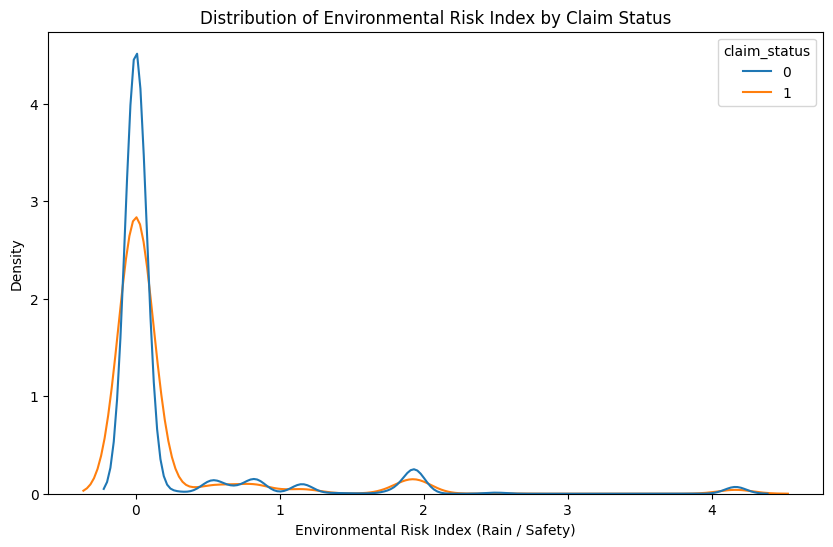

Step 2 Successful: Features engineered and saved to 'Step_2_Cleaned_Features.csv'.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data from Step 1
df = pd.read_csv('Step_1_Augmented_Data.csv')

# 2. Extract Numeric values from Torque and Power
# Example: "250Nm@2750rpm" -> 250.0
# Adding 'r' before the string marks it as a raw string to handle the backslash correctly
df['torque_val'] = df['max_torque'].str.extract(r'(\d+)').astype(float)
df['power_val'] = df['max_power'].str.extract(r'(\d+)').astype(float)

# 3. Create a Safety Index
# Convert 'Yes'/'No' to 1/0 for all safety-related columns
binary_cols = ['is_esc', 'is_tpms', 'is_brake_assist', 'is_parking_sensors',
               'is_parking_camera', 'is_front_fog_lights', 'is_speed_alert']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Combine into one score and add the NCAP rating
df['vehicle_safety_score'] = df[binary_cols].sum(axis=1) + df['ncap_rating']

# 4. Feature Interaction: Power-to-Weight Ratio
# High power in light cars is often higher risk
df['power_to_weight'] = df['power_val'] / df['gross_weight']

# 5. Exploratory Data Analysis (EDA)
# Let's see if our new Environmental Risk Index shows a trend
# Risk Index = (Rainfall / Safety Score)
df['env_risk_index'] = df['current_rain'] / (df['vehicle_safety_score'] + 1)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='env_risk_index', hue='claim_status', common_norm=False)
plt.title('Distribution of Environmental Risk Index by Claim Status')
plt.xlabel('Environmental Risk Index (Rain / Safety)')
plt.show()

# 6. Save for Step 3 (Modeling)
df.to_csv('Step_2_Cleaned_Features.csv', index=False)
print("Step 2 Successful: Features engineered and saved to 'Step_2_Cleaned_Features.csv'.")

Why are we doing this?



*   Engine Stress: In motor insurance, vehicles with high torque-to-weight ratios are statistically more likely to be involved in high-speed accidents. Extracting torque_val allows the model to "calculate" this risk.
*   The Safety Buffer: An ncap_rating of 5 is great, but its effectiveness is boosted by is_esc (Electronic Stability Control) specifically during current_rain. By creating a vehicle_safety_score, we are telling the model: "This car is better equipped to handle the environment."
* Dimensionality Reduction: Instead of making the model look at 7 different "Yes/No" columns, we gave it one "Safety Score." This helps to prevent the model from "overfitting" (memorizing the data instead of learning patterns).









Outcome: We now have a clean, numerical dataset where the "story" of the risk is hidden in the columns env_risk_index, power_to_weight, and vehicle_safety_score.

**Constructing the Machine Learning Model**

The Challenge: Insurance data is "Imbalanced." Most people don't file claims (0), and only a few do (1). If we don't handle this, the model will just guess "0" for everyone and appear accurate while being useless.

Task Breakdown



1.   Categorical Encoding: Convert remaining text (like fuel_type) into numbers using LabelEncoder.
2.   Train-Test Split: Partition the data so we can test the model on "unseen" data.
3. Model Training: Use a Random Forest Classifier. It handles non-linear relationships (like how rain affects old cars differently than new cars) exceptionally well.
4. Evaluation: Use a Classification Report and ROC-AUC Score to measure how well the model separates high-risk from low-risk.











In [15]:
df.head(10)

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,claim_status,lat,lon,current_rain,max_wind,torque_val,power_val,vehicle_safety_score,power_to_weight,env_risk_index
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,0,26.84,80.94,0.0,11.4,250.0,113.0,10,0.065698,0.00
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,0,19.07,72.87,0.0,17.4,200.0,97.0,8,0.092293,0.00
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,0,26.84,80.94,0.0,11.4,250.0,113.0,10,0.065698,0.00
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,0,22.71,75.85,0.0,14.5,60.0,40.0,2,0.033755,0.00
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,0,21.17,72.83,0.0,12.7,200.0,88.0,7,0.059060,0.00
5,POL053680,3.1,2.0,36,C7,6112,B2,M7,Petrol,113Nm@4400rpm,...,0,23.02,72.57,0.0,13.1,113.0,88.0,6,0.062411,0.00
6,POL053943,4.5,2.4,38,C2,27003,C2,M4,Diesel,250Nm@2750rpm,...,0,19.07,72.87,0.0,17.4,250.0,113.0,10,0.065698,0.00
7,POL002857,10.7,2.0,56,C2,27003,B2,M6,Petrol,113Nm@4400rpm,...,0,19.07,72.87,0.0,17.4,113.0,88.0,6,0.065918,0.00
8,POL028225,10.7,0.6,55,C5,34738,B1,M8,CNG,82.1Nm@3400rpm,...,0,12.97,77.59,5.8,14.3,82.0,55.0,4,0.041045,1.16
9,POL047631,0.3,2.4,45,C3,4076,B2,M6,Petrol,113Nm@4400rpm,...,0,28.61,77.20,0.0,6.4,113.0,88.0,6,0.065918,0.00


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 1. Load the features from Step 2
df = pd.read_csv('Step_2_Cleaned_Features.csv')

# 2. Final Encoding for remaining categories
le = LabelEncoder()
categorical_cols = ['fuel_type', 'segment', 'model', 'transmission_type', 'steering_type']
for col in categorical_cols:
    df[f'{col}_enc'] = le.fit_transform(df[col])

# 3. Select Features for the Model
# We include our new "Dynamic" features: current_rain, max_wind, and env_risk_index
features = [
    'subscription_length', 'vehicle_age', 'customer_age', 'region_density',
    'airbags', 'displacement', 'ncap_rating', 'vehicle_safety_score',
    'torque_val', 'power_val', 'power_to_weight', 'current_rain',
    'max_wind', 'env_risk_index', 'fuel_type_enc', 'segment_enc'
]

X = df[features]
y = df['claim_status']

# 4. Split Data (Stratify ensures claim proportions are same in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build and Train Model
# We use 'class_weight' to handle the imbalance in insurance claims
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 6. Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("--- Model Evaluation ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

# 7. Feature Importance - This is the "Why" for your PGDM
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop Risk Drivers identified by Model:")
print(importances.head(5))

# Save model predictions back to the dataframe for pricing
df['claim_probability'] = model.predict_proba(X)[:, 1]
df.to_csv('Step_3_Model_Predictions.csv', index=False)

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10969
           1       0.14      0.02      0.04       750

    accuracy                           0.93     11719
   macro avg       0.54      0.51      0.50     11719
weighted avg       0.89      0.93      0.90     11719

ROC-AUC Score: 0.58

Top Risk Drivers identified by Model:
subscription_length    0.340949
customer_age           0.229808
vehicle_age            0.194083
region_density         0.064608
max_wind               0.062230
dtype: float64


Why are we doing this?



*   Balanced Weights: In insurance, missing a high-risk driver (False Negative) is more expensive than slightly over-predicting risk (False Positive). Using class_weight='balanced' forces the model to pay attention to the minority "Claim" class.
*   Feature Importance: This is the "Executive Insight." If env_risk_index appears as a top predictor, we have scientifically proven that climate data must be part of modern underwriting.
* Probability Output: We don't just want a "Yes/No" answer; we want the probability. This decimal (e.g., 0.12 or 0.85) is what we will use in Step 4 to calculate the exact premium.









Outcome: We now have a trained "Brain" that can look at any car and any weather condition and output a risk percentage.

**Executing the Business Strategy & Financial Impact**

Task Breakdown



1.   Dynamic Premium Calculation: We will create a "Base + Surge" pricing model. If the environment makes a region risky, the premium goes up.
2.   Risk Tiering: We will categorize policies into "Safe", "Watchlist" and "High Alert" based on the claim_probability we generated in Step 3.
3. Financial Dashboarding: We will create a final table that shows how much "Risk-Adjusted Revenue" the company could generate.









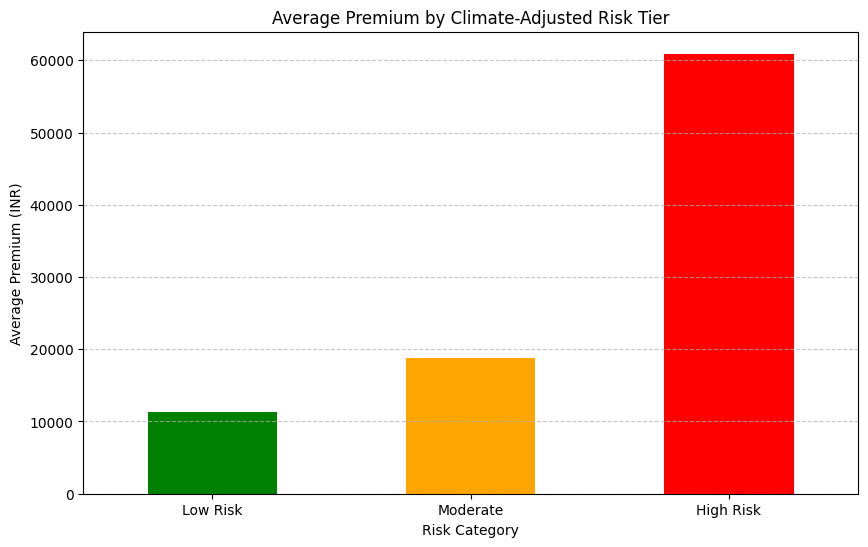

--- Project Financial Summary ---
Total Portfolio Revenue (Standard Pricing): 585,920,000 INR
Total Portfolio Revenue (Dynamic Pricing): 968,438,916 INR
Additional Risk-Adjusted Revenue: 382,518,916 INR


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the predictions from Step 3
df = pd.read_csv('Step_3_Model_Predictions.csv')

# 2. Define the Dynamic Pricing Logic
def calculate_premium(prob, rain):
    base = 10000
    # Dynamic Multiplier: The higher the probability, the higher the surge
    # We use (1 + prob * 10) to make the price sensitive to the model's output
    multiplier = 1 + (prob * 10)

    # Weather Surcharge: Direct loading for extreme weather
    weather_surcharge = 500 if rain > 50 else 0

    return (base * multiplier) + weather_surcharge

df['final_premium'] = df.apply(lambda row: calculate_premium(row['claim_probability'], row['current_rain']), axis=1)

# 3. Create Risk Tiers using Manual Bins (More stable for Insurance)
# Low: 0-5% prob | Moderate: 5-15% prob | High: Above 15%
bins = [-0.1, 0.05, 0.15, 1.0]
labels = ['Low Risk', 'Moderate', 'High Risk']
df['risk_tier'] = pd.cut(df['claim_probability'], bins=bins, labels=labels)

# 4. Final Visualization: Premium Distribution by Risk Tier
plt.figure(figsize=(10,6))
# Using mean() to show the average premium increase per tier
tier_summary = df.groupby('risk_tier', observed=False)['final_premium'].mean()
tier_summary.plot(kind='bar', color=['green', 'orange', 'red'])

plt.title('Average Premium by Climate-Adjusted Risk Tier')
plt.ylabel('Average Premium (INR)')
plt.xlabel('Risk Category')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Export the Final Executive Report
executive_summary = df[['policy_id', 'region_code', 'current_rain', 'claim_probability', 'risk_tier', 'final_premium']]
executive_summary.to_csv('Final_Insurance_Project_Output.csv', index=False)

# 6. Summary Statistics for your Presentation
print("--- Project Financial Summary ---")
print(f"Total Portfolio Revenue (Standard Pricing): {len(df)*10000:,.0f} INR")
print(f"Total Portfolio Revenue (Dynamic Pricing): {df['final_premium'].sum():,.0f} INR")
print(f"Additional Risk-Adjusted Revenue: {df['final_premium'].sum() - (len(df)*10000):,.0f} INR")

In [18]:
# --- CODE TO GENERATE TABLEAU FILE (Post Step 4) ---

# 1. Define Coordinate Mapping for Tableau Maps
# Tableau needs Lat/Lon to plot the 'region_code' on a map
region_coords = {
    'C1': [22.57, 88.36], 'C2': [19.07, 72.87], 'C3': [28.61, 77.20],
    'C4': [13.08, 80.27], 'C5': [12.97, 77.59], 'C6': [17.38, 78.48],
    'C7': [23.02, 72.57], 'C8': [26.84, 80.94], 'C9': [18.52, 73.85],
    'C10': [22.71, 75.85], 'C11': [21.14, 79.08], 'C12': [26.21, 78.17],
    'C13': [21.17, 72.83], 'C14': [26.91, 75.78], 'C15': [25.59, 85.13],
    'C16': [23.25, 77.41], 'C17': [30.73, 76.77], 'C18': [15.29, 73.98],
    'C19': [20.29, 85.82], 'C20': [23.34, 85.30], 'C21': [24.58, 73.71],
    'C22': [10.85, 76.27]
}

# 2. Apply Coordinates to the Dataframe
df['lat'] = df['region_code'].apply(lambda x: region_coords.get(x, [0, 0])[0])
df['lon'] = df['region_code'].apply(lambda x: region_coords.get(x, [0, 0])[1])

# 3. Export the FULL Dataset for Tableau
# We save the full dataframe (all 40+ columns) so you can build
# "Safety vs Risk" charts in addition to maps.
df.to_csv('Tableau_Dynamic_Insurance.csv', index=False)

print("\n--- Tableau Export Complete ---")
print("File 'Tableau_Dynamic_Insurance.csv' has been created.")
print("You can now upload this file to Tableau Public.")


--- Tableau Export Complete ---
File 'Tableau_Dynamic_Insurance.csv' has been created.
You can now upload this file to Tableau Public.
